In [4]:
import os
import geopandas as gpd
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

llm = ChatOpenAI(
    model=os.getenv("CHAT_MODEL"),
    base_url=os.getenv("BASE_URL") + "/v1",
    temperature=float(os.getenv("TEMPERATURE", "0")),
    api_key=os.getenv("OPENAI_API_KEY") or "dummy",
)

import geopandas as gpd

baseline_blocks = gpd.read_file('./data/gatchina/blocks_clean_gatchina.geojson')
baseline_blocks.head()



,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,gsi,mxi,l,morphotype,area_accessibility,site_area,land_value,land_value_per_100m2,id,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,0.008829,0.091908,1.371459,individual residential,10.063987,215420.389645,4.523965e+08,210006.365794,0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,0.036428,0.712492,5.824002,mid-rise,10.210398,108166.972589,6.273598e+08,579991.970625,1,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,0.075903,0.198114,2.288643,low-rise model,7.467434,32058.270586,1.065881e+08,332482.363541,3,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
3,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,0.071648,0.095598,2.187029,low-rise model,8.285434,30779.356283,8.802486e+07,285986.682700,4,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."
4,0.262580,0.000000,0.000186,0.0,0.737236,0.0,0.0,LandUse.TRANSPORT,0.737236,1946.641824,...,0.013231,0.337680,1.149477,individual residential,10.294833,37909.234921,8.177854e+07,215721.956498,5,"POLYGON ((30.13162 59.55046, 30.1319 59.55029,..."


In [5]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('./data/catboost_land_value_no_services.cbm')  # модель на лог-цене
print(len(model.feature_names_))

feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]

101


In [6]:
from urbanomy.methods.agent_interface import (
    DistrictOptimizationConfig,
    create_urbanomy_orchestrator,
)


opt_config = DistrictOptimizationConfig(
    model=model,
    orig_features=numeric_feats + cat_features,
    categorical_features=cat_features,
)

orchestrator = create_urbanomy_orchestrator(
    llm=llm,
    baseline_blocks=baseline_blocks,
    district_optimization_config=opt_config,
)

orchestrator.set_thread("demo2")


'demo2'

In [ ]:
orchestrator("что такое город?")


Город — это крупный населённый пункт с развитой инфраструктурой, где сосредоточены жильё, работа, образование, культура и услуги. Он обычно имеет административный статус, собственное управление и более плотную застройку, чем в сельской местности. Город служит центром экономической, социальной и культурной жизни региона.

In [ ]:
orchestrator("что ты умеешь?")

Я могу:

- отвечать на общие вопросы на русском;
- объяснять, какие функции доступны в orchestrator;
- перечислять и описывать инструменты, такие как визуализация стоимости земли, оптимизация квартала, построение Pareto‑front и т.д.

Если нужен более детальный список возможностей или текущий контекст последней оптимизации, я могу запросить их у orchestrator.

In [ ]:
orchestrator("какие инструменты у тебя есть?")

У меня есть следующие инструменты (их возможности задаёт orchestrator):

- визуализация полной стоимости земли  
- визуализация стоимости земли за сотку  
- выделение квартала по `target_id`  
- оптимизация квартала по `target_id`  
- вывод количества найденных оптимальных решений  
- визуализация конкретного решения из Pareto‑front  
- вывод параметров квартала для конкретного решения  
- расчёт инвестиционных метрик для решения  
- построение графика Pareto‑front  

Кроме этого я отвечаю на общие вопросы и объясняю, как пользоваться этими функциями.

In [ ]:
orchestrator("что такое target_id")

`target_id` — это идентификатор (обычно числовой или строковый), который однозначно указывает на конкретный объект, ресурс или запись в системе. Его используют в API, базах данных и других интерфейсах, чтобы указать, к какому именно «целевому» элементу следует обратиться (например, к пользователю, заказу, файлу и т.п.).

In [ ]:
orchestrator("2+2?")

2 + 2 = 4.

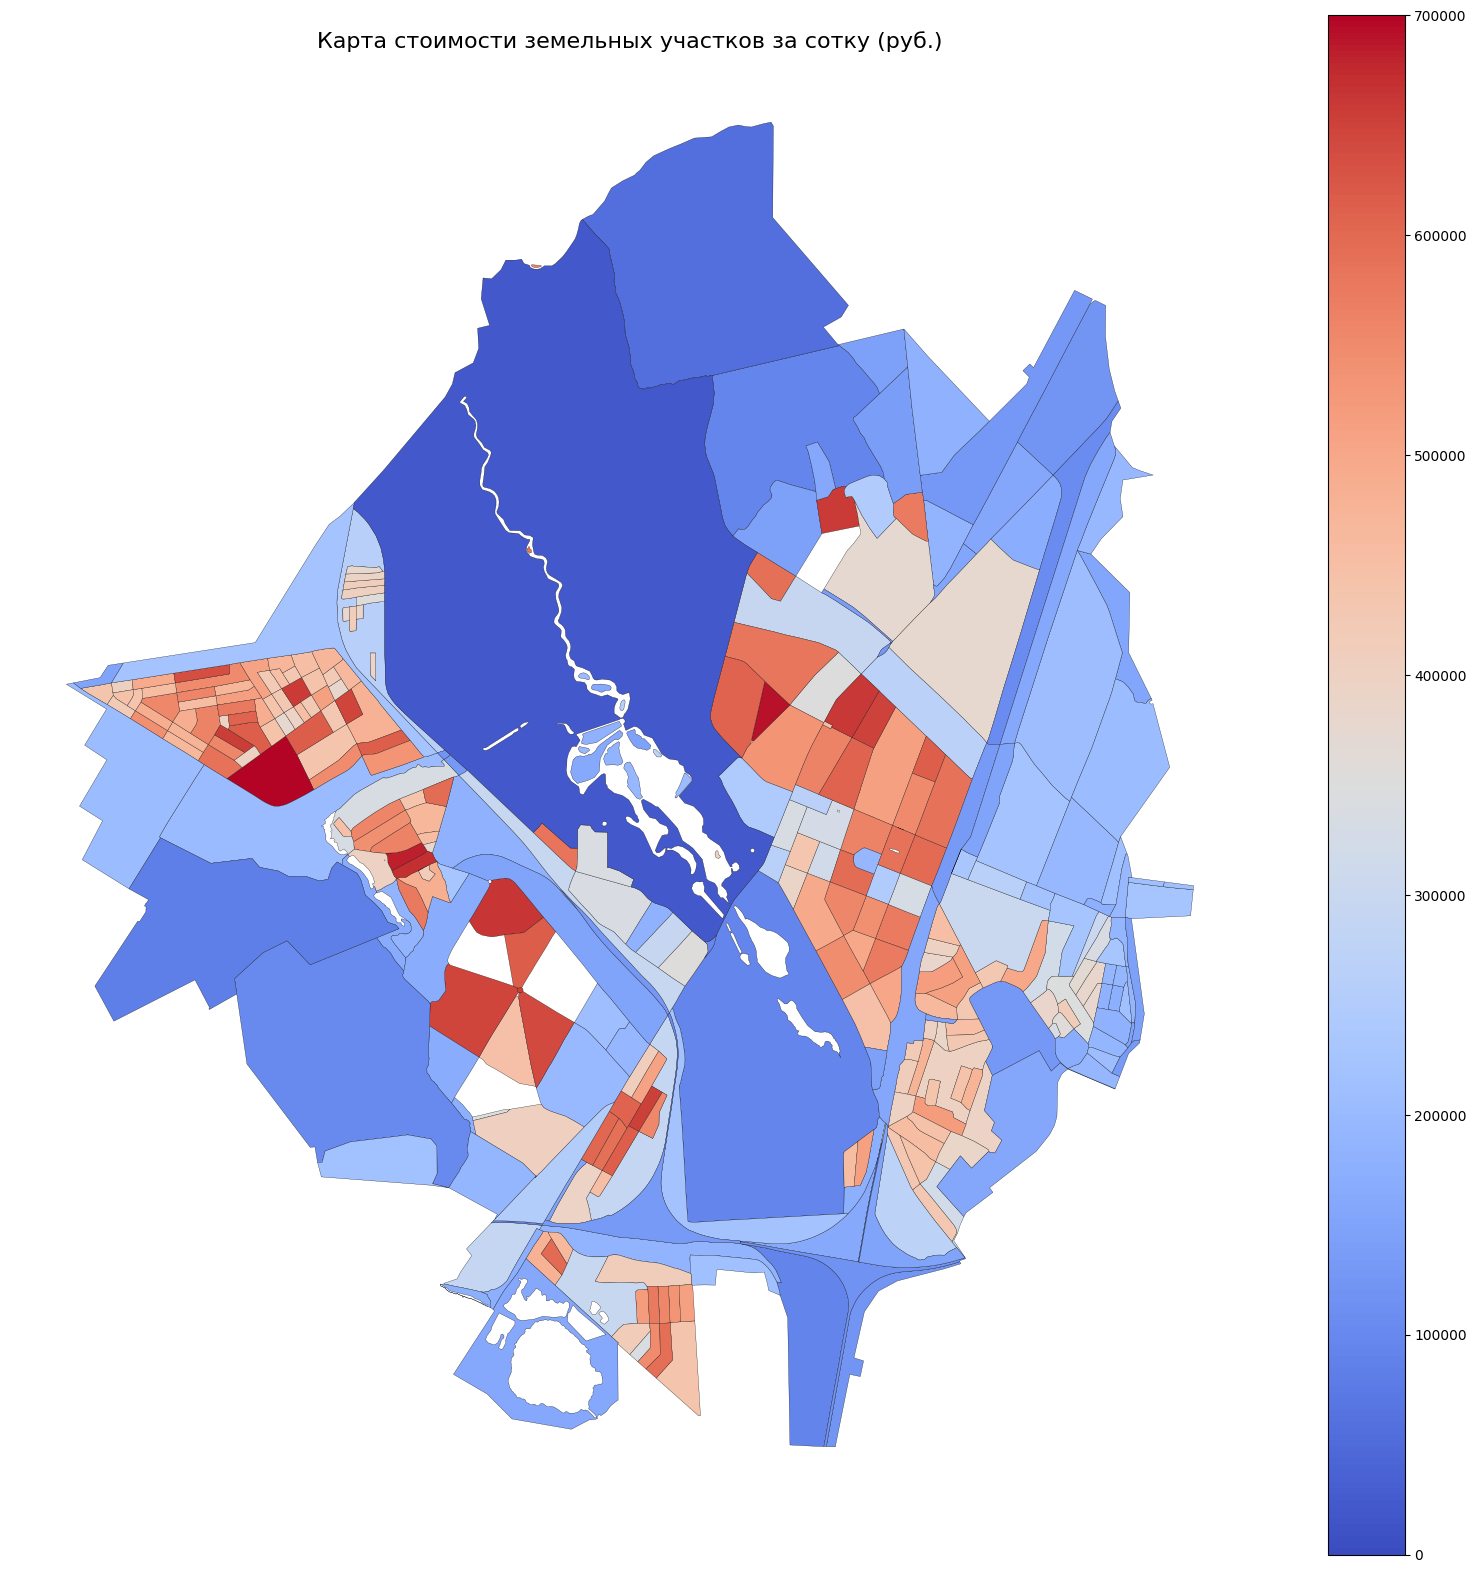

TypeError: Type is not msgpack serializable: LandValueVisualizationResult

In [ ]:
result = orchestrator("Покажи стоимость земли за сотку")

/home/mvin/Urbanomy/src/urbanomy/methods/agent_interface/tools/_plotting.py:111: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)


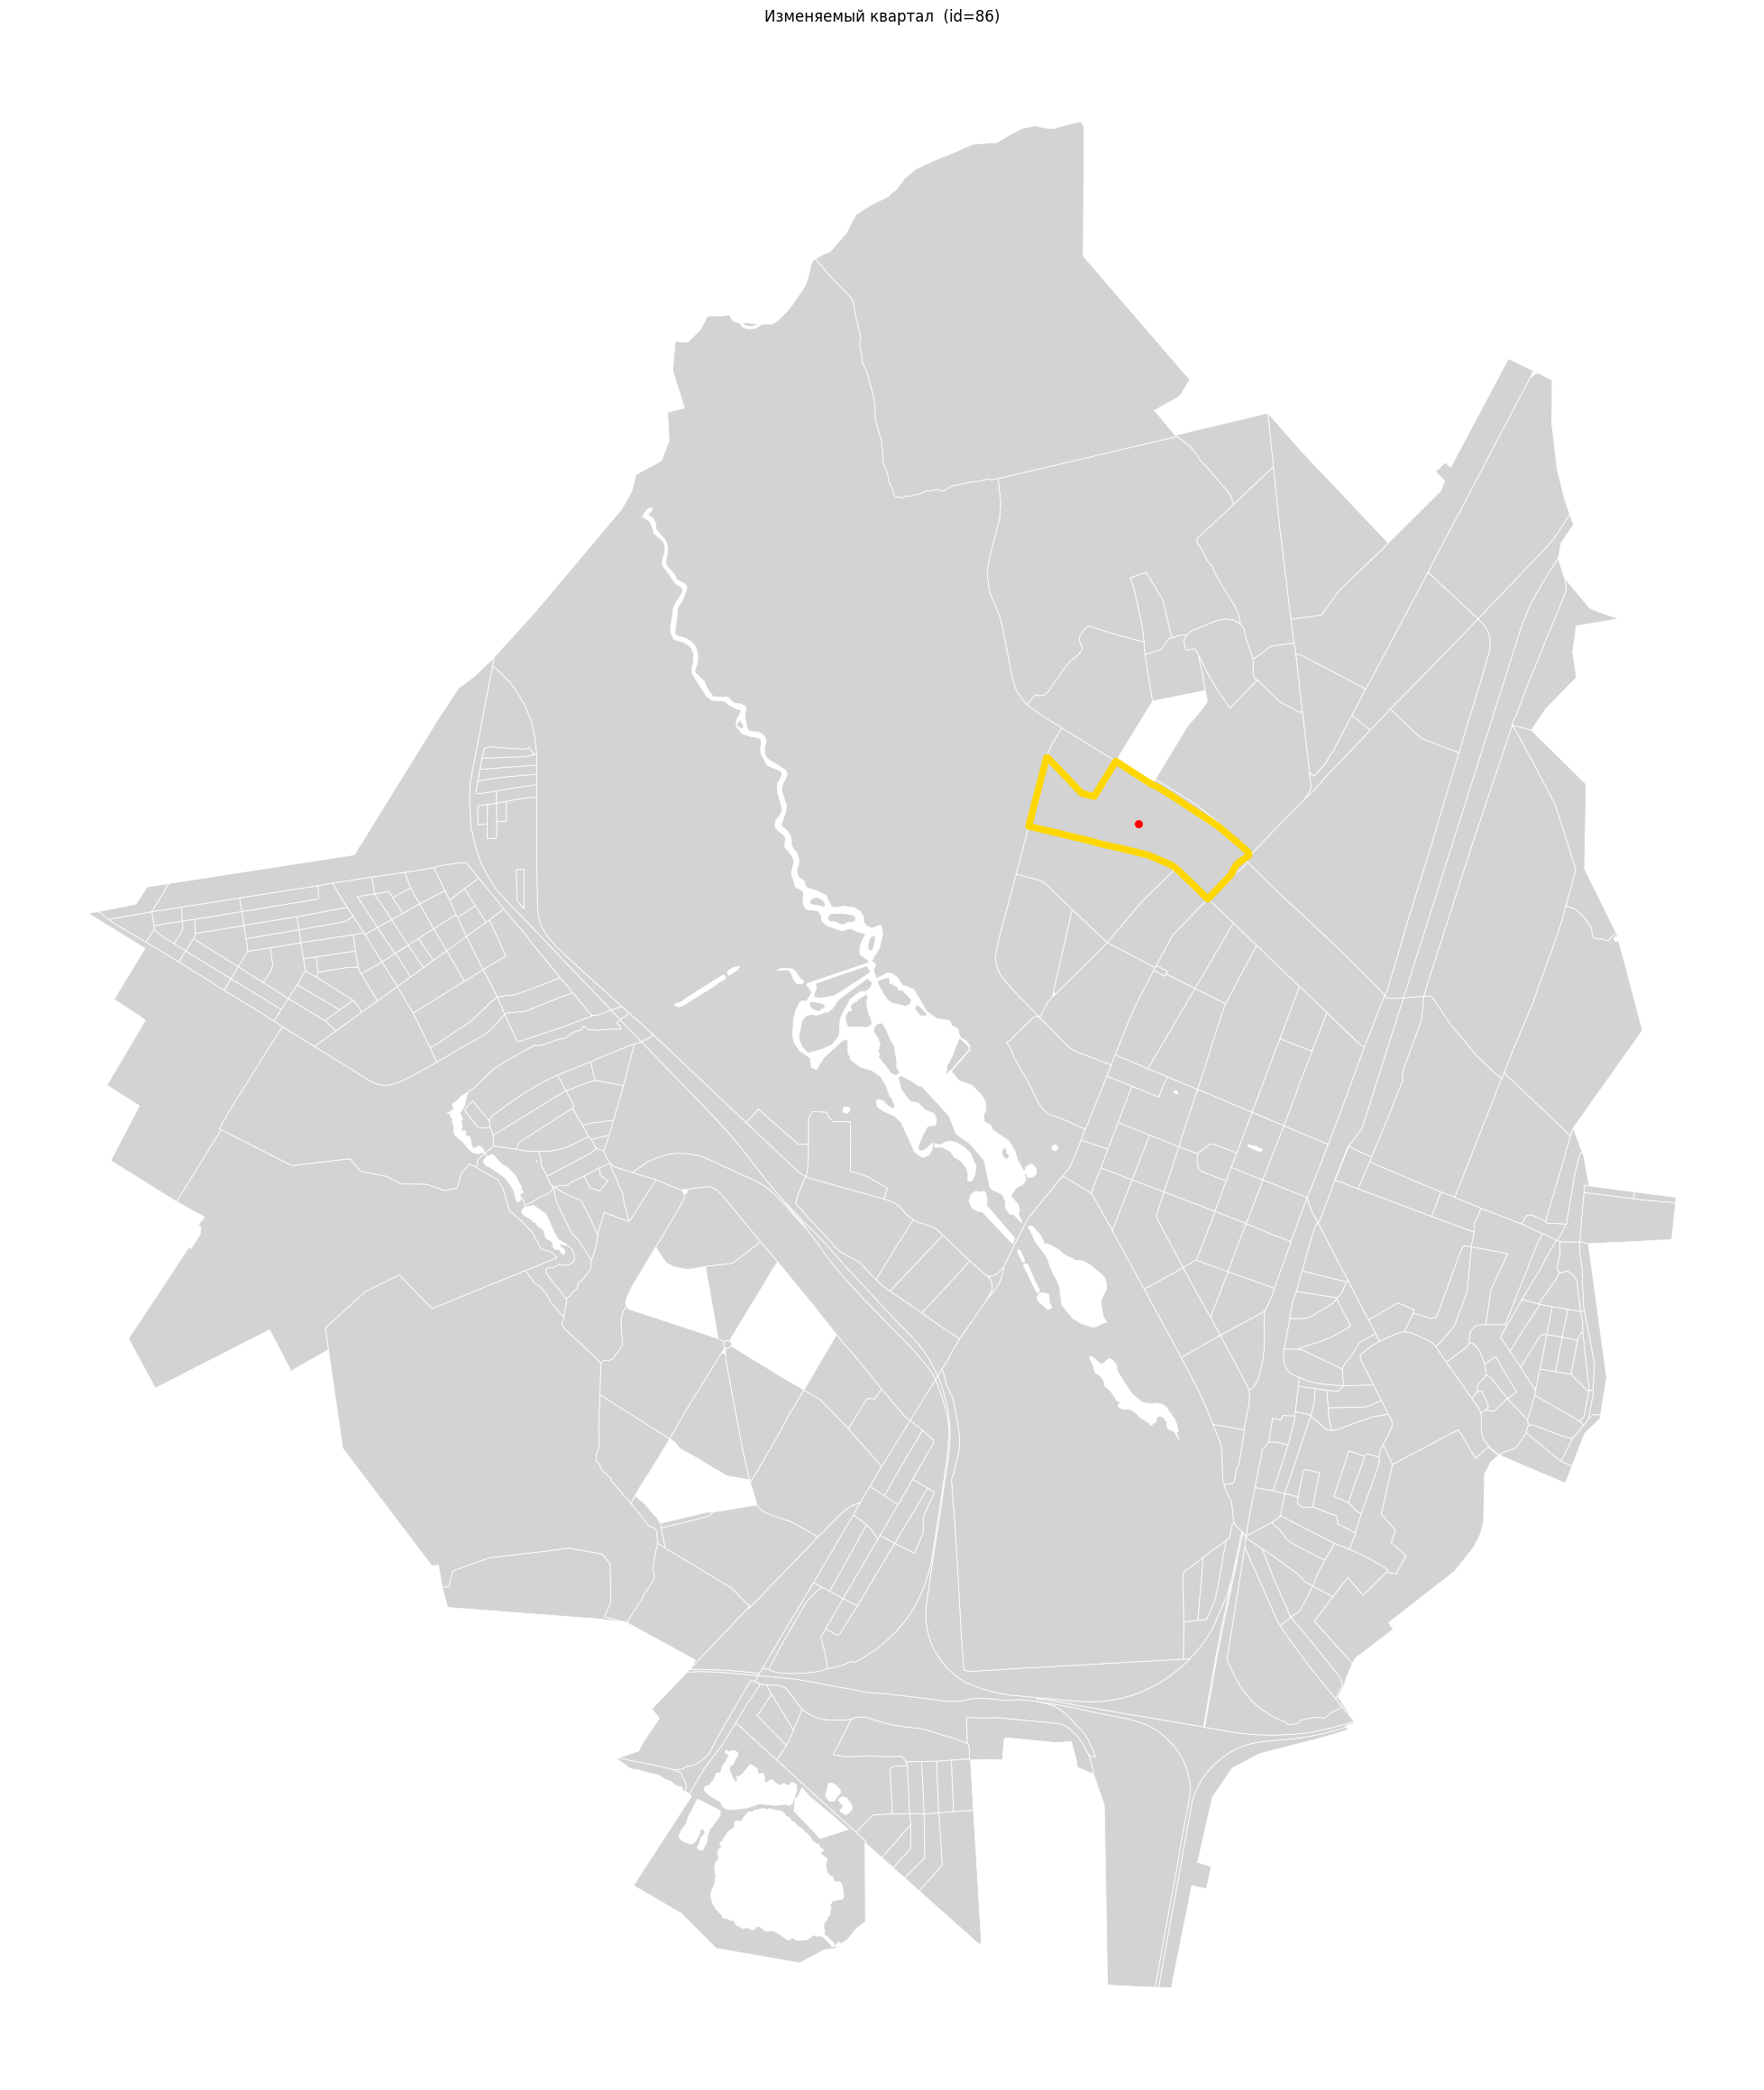

TypeError: Type is not msgpack serializable: TargetBlockVisualizationResult

In [ ]:
orchestrator("Покажи квартал с target_id=86")

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       10 |      1 |             - |             -
     2 |       20 |      1 |  6.622146E+07 |         ideal
     3 |       30 |      2 |  1.0000000000 |         ideal
     4 |       40 |      1 |  4.449188E+08 |         ideal
     5 |       50 |      1 |  4.882480E+07 |         ideal
     6 |       60 |      4 |  0.9978987572 |         ideal
     7 |       70 |      1 |  1.376257E+08 |         ideal
     8 |       80 |      3 |  0.4808934655 |         ideal
     9 |       90 |      2 |  1.1076620282 |         ideal
    10 |      100 |      1 |  2.458242E+08 |         ideal
    11 |      110 |      2 |  1.0000000000 |         ideal
    12 |      120 |      3 |  0.0479566371 |         ideal
    13 |      130 |      3 |  0.1803217805 |         ideal
    14 |      140 |      4 |  0.0137609835 |         ideal
    15 |      150 |      4 |  0.1785858123 |         ideal


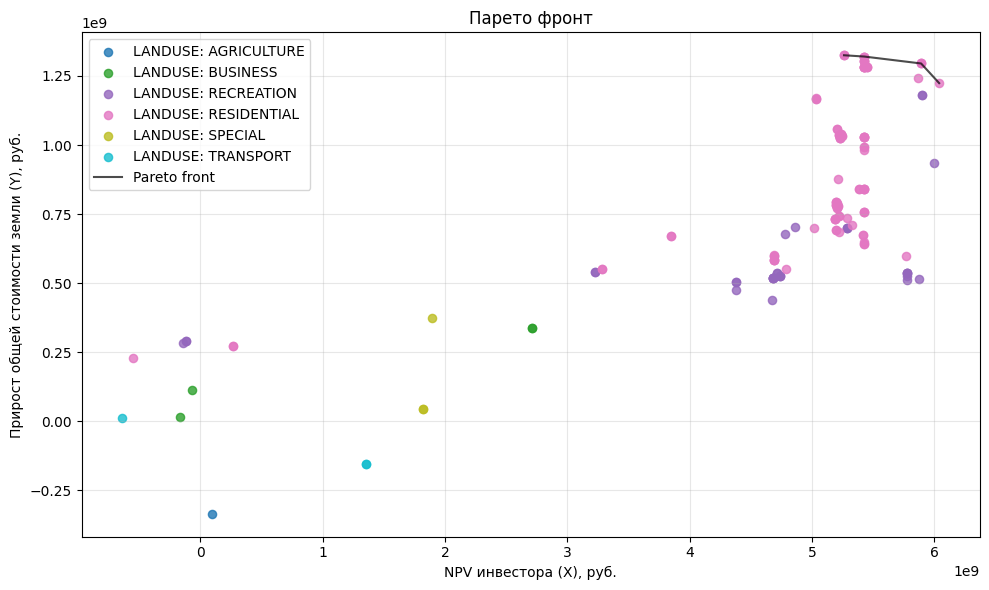

Оптимизация завершена. Найдено 4 оптимальных решения.

Построен график Парето-фронта.
 • Всего точек: 150
 • Точек на фронте: 4
 • Категории LANDUSE: AGRICULTURE, BUSINESS, RECREATION, RESIDENTIAL, SPECIAL, TRANSPORT

In [ ]:
orchestrator("Оптимизируй квартал с target_id=86")

In [ ]:
orchestrator("что такое RESIDENTIAL?")

**Residential** — термин, обозначающий жилую часть города или района, где расположены дома, квартиры и другие помещения, предназначенные для постоянного проживания людей. Обычно в таком контексте речь идёт о жилой застройке, жилых кварталах, жилых комплексах и инфраструктуре, обслуживающей жителей.

In [ ]:
orchestrator("какие парамерты застройки в решение 2")

Параметры квартала для решения 2:
 • footprint_area: 25390.982188
 • l: 9.527336
 • mxi: 0.994576
 • residential: 0.342944
 • business: 0.228597
 • recreation: 0.341039
 • industrial: 0.002966
 • transport: 0.07939
 • special: 0.002815
 • agriculture: 0.002248
 • share: 0.342944
 • land_use: LandUse.RESIDENTIAL
 • build_floor_area: 241908.430552
 • living_area: 240596.253607
 • non_living_area: 1312.176945
 • population: 12029.81268
 • fsi: 0.922431
 • gsi: 0.096819
 • morphotype: high-rise soviet microdistrict

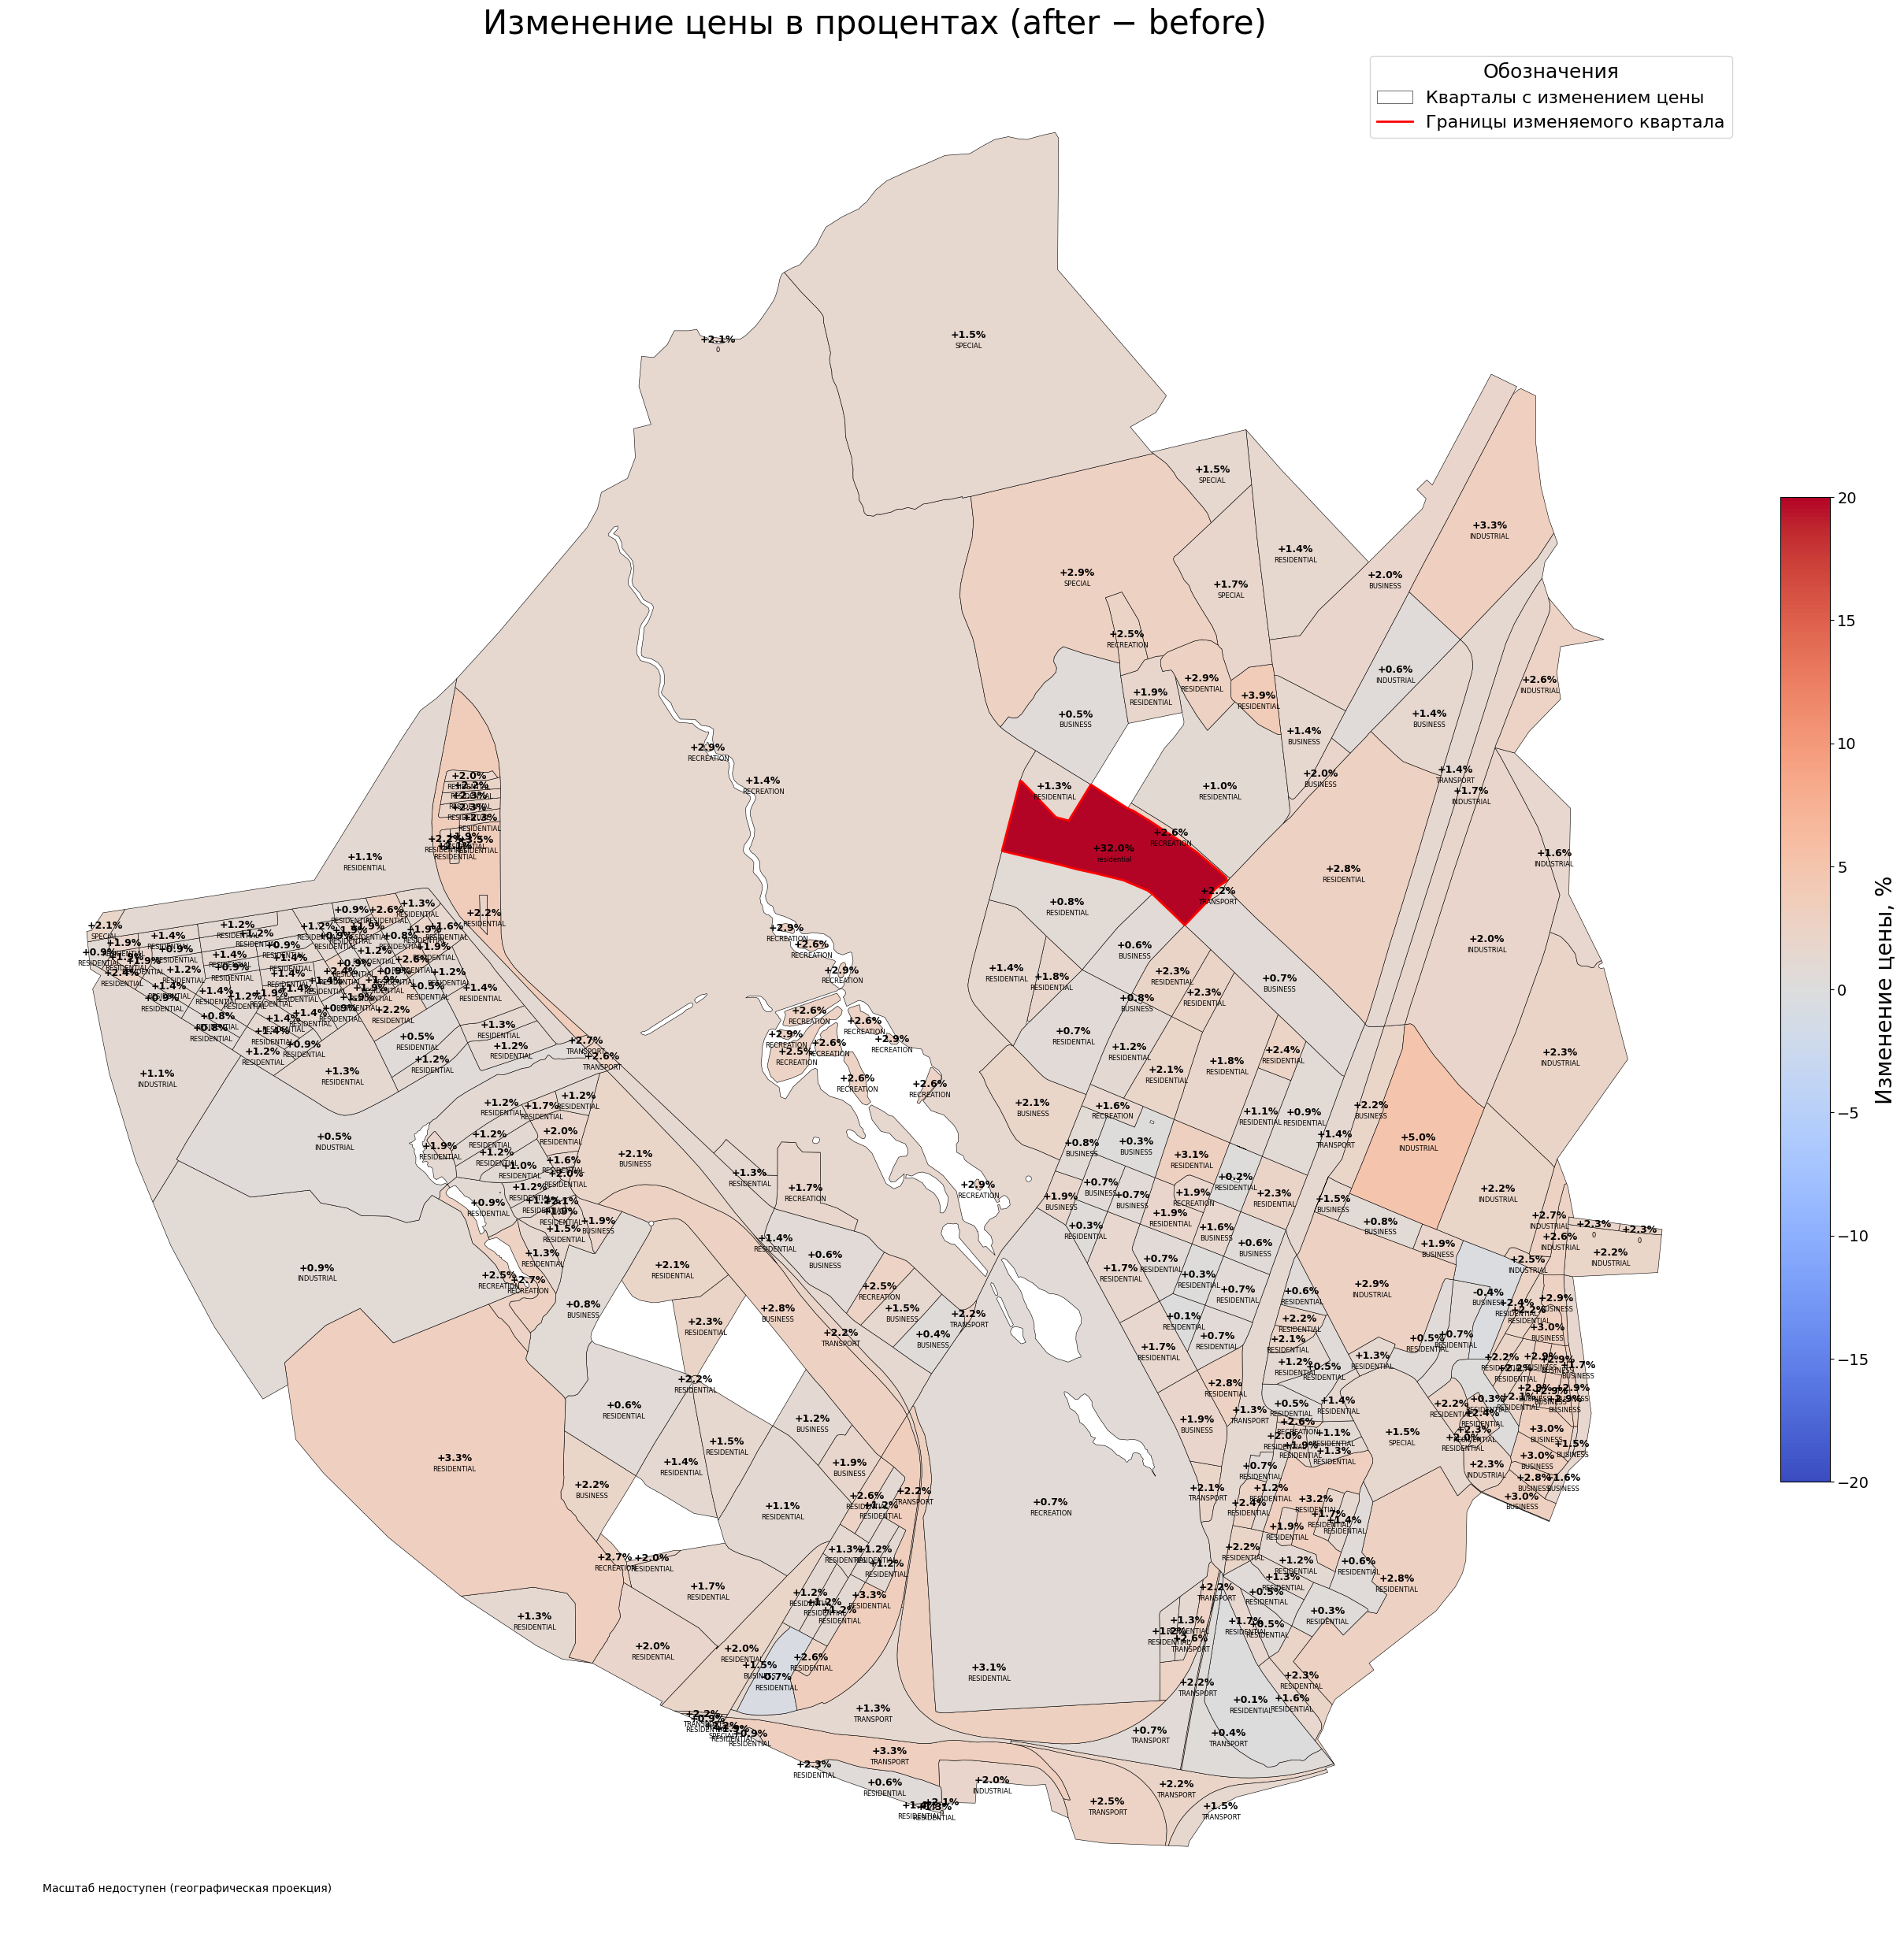

Изменение стоимости земли по всем кварталам:
 • Сумма до:    66 304 589 810 ₽
 • Сумма после: 67 629 643 205 ₽
 • Изм., ₽:     +1 325 053 394 ₽
 • Изм., %:     +2.00%

Изменяемый квартал:
 • До: 741 498 772 ₽ | После: 978 601 523 ₽ | Δ: +237 102 751 ₽ | Δ%: +31.98%

In [ ]:
orchestrator("Визуализируй подорожание земли в решение 3")

In [ ]:
orchestrator("Посчитай инвестиционные метрики для решения 2")

Project totals:
 • Land area:          262,250.98
 • Built area:         241,908.43
 • Land value:         741,498,771.81
 • Demolition cost:    96,396,921.16
 • Construction cost:  10,868,949,516.37
 • Investment need:    11,706,845,209.34
 • Project NPV:        5,920,911,893.72
 • Project IRR:        0.35
 • Project PI:         1.59
 • Project PP (yrs):   5.21

In [ ]:
orchestrator("Что ты запомнил?")

Я запомнил текущий контекст последней оптимизации:

- **target_id:** 86  
- **Найдено решений:** 4  
- **Решения:**  
  1. scenario_0 | RESIDENTIAL | NPV = 5 427 989 082.65  
  2. scenario_1 | RESIDENTIAL | NPV = 5 893 215 666.10  
  3. scenario_2 | RESIDENTIAL | NPV = 5 263 090 570.92  
  4. scenario_3 | RESIDENTIAL | NPV = 6 040 916 464.51  

Также в истории есть запросы о параметрах решений, визуализации стоимости земли и расчёте инвестиционных метрик. Если нужно подробнее о каком‑либо решении или выполнить новую задачу – дайте знать.

In [ ]:
from IPython.display import Image, Markdown, display

from urbanomy.methods.agent_interface import create_urbanomy_orchestrator

orchestrator = create_urbanomy_orchestrator(
    llm=llm,
    baseline_blocks=baseline_blocks,
)



def show_graph(title, compiled_graph, xray=False):
    display(Markdown(f"### {title}"))
    try:
        display(Image(compiled_graph.get_graph(xray=xray).draw_mermaid_png()))
    except Exception:
        mermaid = compiled_graph.get_graph(xray=xray).draw_mermaid()
        display(Markdown(f"```mermaid\n{mermaid}\n```"))


show_graph("Orchestrator", orchestrator.graph, xray=True)


### Orchestrator

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	router(router)
	land_value_visualization(land_value_visualization)
	target_block_visualization(target_block_visualization)
	district_optimization(district_optimization)
	general_qa(general_qa)
	unsupported(unsupported)
	finalize(finalize)
	__end__([<p>__end__</p>]):::last
	__start__ --> router;
	district_optimization --> finalize;
	general_qa --> finalize;
	land_value_visualization --> finalize;
	router -.-> district_optimization;
	router -.-> general_qa;
	router -.-> land_value_visualization;
	router -.-> target_block_visualization;
	router -.-> unsupported;
	target_block_visualization --> finalize;
	unsupported --> finalize;
	finalize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```